# Histopathologic Cancer Detection EDA


In [ ]:
# =========================
# 1. Imports & Config
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import torch

# Paths
# Need to change path
TRAIN_DIR = Path('/Users/picsartacademy/Desktop/cancer detection final/CancerDetectionProject/data/train')
TEST_DIR  = Path('/Users/picsartacademy/Desktop/cancer detection final/CancerDetectionProject/data/test')
LABELS_CSV = Path('/Users/picsartacademy/Desktop/cancer detection final/CancerDetectionProject/data/train_labels.csv')

# Config
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Configuration loaded successfully.")

Configuration loaded successfully.


In [20]:
# Load labels
df = pd.read_csv(LABELS_CSV)

print(f"Total number of images: {len(df):,}")
print("\nFirst 5 rows:")
print(df.head())

Total number of images: 220,025

First 5 rows:
                                         id  label
0  f38a6374c348f90b587e046aac6079959adf3835      0
1  c18f2d887b7ae4f6742ee445113fa1aef383ed77      1
2  755db6279dae599ebb4d39a9123cce439965282d      0
3  bc3f0c64fb968ff4a8bd33af6971ecae77c75e08      0
4  068aba587a4950175d04c680d38943fd488d6a9d      0


## Picture samples

All pictures: 220,025
label
0    130908
1     89117
Name: count, dtype: int64


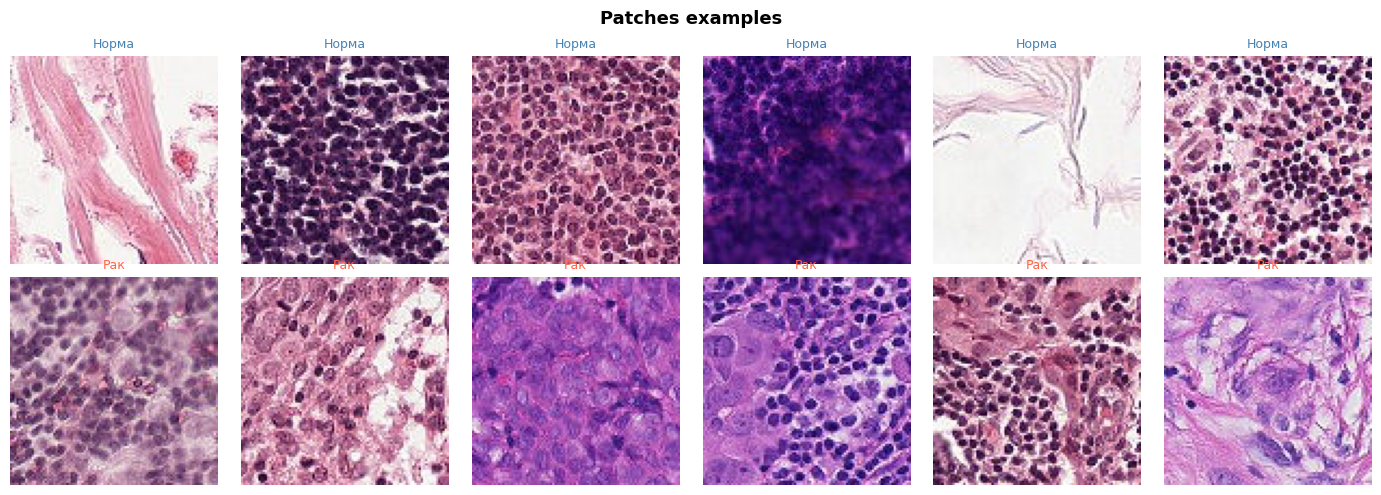

In [21]:
df = pd.read_csv(LABELS_CSV)
print(f"All pictures: {len(df):,}")
print(df["label"].value_counts())

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for label, row_axes in zip([0, 1], axes):
    samples = df[df["label"] == label].sample(6, random_state=SEED)
    for ax, (_, row) in zip(row_axes, samples.iterrows()):
        img = Image.open(TRAIN_DIR / f"{row['id']}.tif")
        ax.imshow(img)
        ax.axis("off")
        ax.set_title("Рак" if label == 1 else "Норма",
                     color="tomato" if label == 1 else "steelblue", fontsize=9)
plt.suptitle("Patches examples", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Class Distribution


Class distribution:
label
0    130908
1     89117
Name: count, dtype: int64


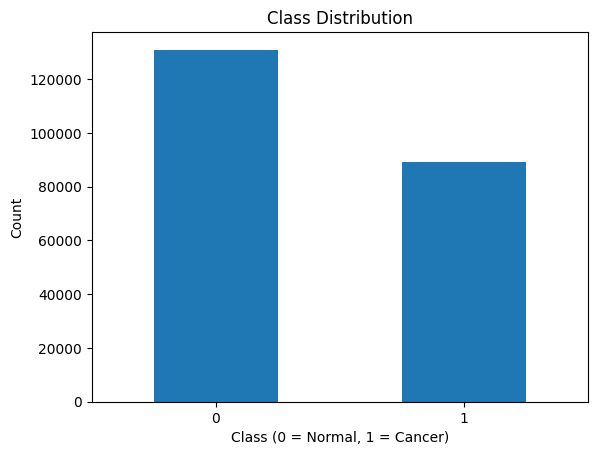


Imbalance ratio (Normal/Cancer): 1.47


In [22]:
print("\nClass distribution:")
print(df["label"].value_counts())

# Plot class distribution
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Cancer)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# Check imbalance ratio
counts = df["label"].value_counts()
ratio = counts[0] / counts[1]

print(f"\nImbalance ratio (Normal/Cancer): {ratio:.2f}")